# 16 PCA

## Import

In [64]:
import time

import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA

from sklearn.model_selection import GridSearchCV, ParameterGrid

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner


import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
mpl.style.use("seaborn-v0_8-colorblind")
RANDOM_STATE = 42

## Dataframe

In [3]:
df_raw = fetch_openml(data_id=42742, as_frame=True).frame

In [4]:
feat_cols = [col for col in df_raw.columns if col not in ("target",)]
cat_cols = [col for col in feat_cols if col.endswith("_cat")]
bin_cols = [col for col in feat_cols if col.endswith("_bin")]
num_cols = [col for col in feat_cols if col not in cat_cols and col not in bin_cols]

for col in cat_cols:
    df_raw[col] = df_raw[col].astype("category")

for col in bin_cols:
    if df_raw[col].isna().sum() == 0:
        df_raw[col] = df_raw[col].astype(int).astype("bool")
    else:
        df_raw[col] = df_raw[col].astype("Int8")

for col in num_cols:
    df_raw[col] = df_raw[col].astype("float32")

df_raw["target"] = df_raw["target"].astype(int).astype("bool")

idx_train = np.load("../../../data/processed/train_idx.npy")
idx_val = np.load("../../../data/processed/val_idx.npy")
idx_test = np.load("../../../data/processed/test_idx.npy")

df_train = df_raw.iloc[idx_train]
df_val = df_raw.iloc[idx_val]
df_test = df_raw.iloc[idx_test]

x_train, y_train = df_train[feat_cols], df_train["target"]
x_val, y_val = df_val[feat_cols], df_val["target"]
x_test, y_test = df_test[feat_cols], df_test["target"]
x_full, y_full = df_raw[feat_cols], df_raw["target"]

idx_train_val = np.concatenate([idx_train, idx_val])
df_train_val = df_raw.iloc[idx_train_val]
x_train_val, y_train_val = df_train_val[feat_cols], df_train_val["target"]

pd.Series(
    {
        "train": [len(df_train), len(x_train), len(y_train)],
        "val": [len(df_val), len(x_val), len(y_val)],
        "test": [len(df_test), len(x_test), len(y_test)],
        "full": [len(df_raw), len(x_full), len(y_full)],
        "train_val": [len(df_train_val), len(x_train_val), len(y_train_val)]
    }
)

train        [476168, 476168, 476168]
val             [59522, 59522, 59522]
test            [59522, 59522, 59522]
full         [595212, 595212, 595212]
train_val    [535690, 535690, 535690]
dtype: object

## Hilfsvariablen

In [5]:
results = []
train_times = {}

In [6]:
calc_cols = [c for c in feat_cols if c.startswith("ps_calc_")]

mv_cols = ["ps_car_03_cat", "ps_car_05_cat", "ps_reg_03", "ps_car_14"]

num_cols_no_calc = [c for c in num_cols if c not in calc_cols]
bin_cols_no_calc = [c for c in bin_cols if c not in calc_cols]
feat_cols_no_calc = [c for c in feat_cols if c not in calc_cols]

high_kard_cols = ["ps_car_11_cat"]
low_kard_cols = [c for c in cat_cols if c not in high_kard_cols]



In [7]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, train_time, best_iter=None):
    """AUC auf Train und Val"""
    auc_train = roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_test": auc_val,
        "gini": 2 * auc_val - 1,
        "delta_auc": auc_train - auc_val,
        "best_iter": best_iter,
        "trainingszeit": train_time
    }

## Encoding

In [14]:
one_hot_prep = make_column_transformer(
    (SimpleImputer(strategy="median"), num_cols_no_calc),
    (OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"), cat_cols),
    ("passthrough", bin_cols_no_calc)
)

In [11]:
target_enc_prep = make_column_transformer(
    (SimpleImputer(strategy="median"), num_cols_no_calc),
    (OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"), low_kard_cols),
    (TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE), high_kard_cols),
    ("passthrough", bin_cols_no_calc)
)

In [15]:
x_train_one_hot = one_hot_prep.fit_transform(x_train[feat_cols_no_calc])
x_val_one_hot = one_hot_prep.transform(x_val[feat_cols_no_calc])

x_train_targ = target_enc_prep.fit_transform(x_train[feat_cols_no_calc], y_train)
x_val_targ = target_enc_prep.transform(x_val[feat_cols_no_calc])

pd.Series({
    "feats raw": len(feat_cols_no_calc),
    "cols nach one hot": x_train_one_hot.shape[1],
    "cols nach target enc": x_train_targ.shape[1],
})

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


feats raw                37
cols nach one hot       193
cols nach target enc     91
dtype: int64

## Scaling

In [18]:
scalers = {
    "ohne scaler": None,
    "minmax": MinMaxScaler(),
    "standard": StandardScaler()
}

In [19]:
pca_vergleich = {}

for name, scaler in scalers.items():
    steps = [PCA(n_components=30, random_state=RANDOM_STATE)]
    if scaler is not None:
        steps.insert(0, scaler)
    pipe = make_pipeline(
        *steps
    ).fit(x_train_one_hot)
    pca_vergleich[name] = pipe["pca"]

In [23]:
df_scaler_pca = pd.DataFrame({
    name : p.explained_variance_ratio_.cumsum() for name, p in pca_vergleich.items()
})

df_scaler_pca

,ohne scaler,minmax,standard
0,0.422909,0.095769,0.027187
1,0.650959,0.164716,0.044595
2,0.766542,0.228844,0.059726
3,0.792190,0.280353,0.074111
4,0.812779,0.327908,0.086941
5,0.828681,0.366056,0.099515
6,0.841413,0.400597,0.111882
7,0.853737,0.434609,0.124024
8,0.863366,0.464729,0.135978
9,0.871751,0.492624,0.147315


In [25]:
df_scaler_pca.index = range(1, 31)
df_scaler_pca

,ohne scaler,minmax,standard
1,0.422909,0.095769,0.027187
2,0.650959,0.164716,0.044595
3,0.766542,0.228844,0.059726
4,0.792190,0.280353,0.074111
5,0.812779,0.327908,0.086941
6,0.828681,0.366056,0.099515
7,0.841413,0.400597,0.111882
8,0.853737,0.434609,0.124024
9,0.863366,0.464729,0.135978
10,0.871751,0.492624,0.147315


Text(0.5, 0.98, 'Scaler Effekt auf PCA')

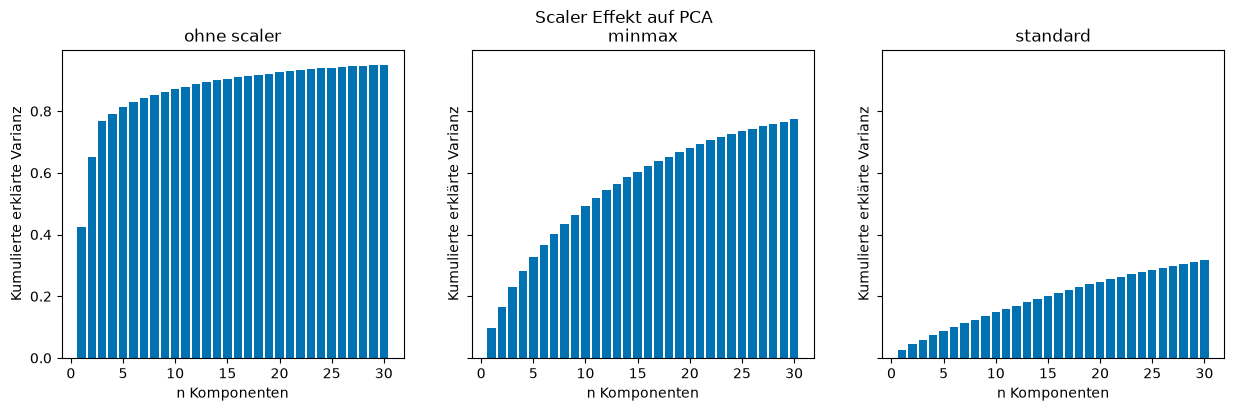

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (name, p) in zip(axes, pca_vergleich.items()):
    ax.bar(range(1,31), p.explained_variance_ratio_.cumsum())
    ax.set_title(name)
    ax.set_xlabel("n Komponenten")
    ax.set_ylabel("Kumulierte erklärte Varianz")

fig.suptitle("Scaler Effekt auf PCA")

## Erklärte Varianz

In [31]:
mm_scaler = MinMaxScaler().fit(x_train_one_hot)

x_train_scale = mm_scaler.transform(x_train_one_hot)
x_val_scale = mm_scaler.transform(x_val_one_hot)

pca_voll = PCA(n_components=None, random_state=RANDOM_STATE).fit(x_train_scale)

erk_var = pca_voll.explained_variance_ratio_
erk_var_cum = erk_var.cumsum()

pd.Series({
    f"{ant} Varianz": int(np.searchsorted(erk_var_cum, ant) + 1) for ant in (0.5, 0.8, 0.9, 0.95, 0.99)
}
|
{
    "Komponenten gesamt": len(erk_var)
})

0.5 Varianz            11
0.8 Varianz            35
0.9 Varianz            62
0.95 Varianz           93
0.99 Varianz          143
Komponenten gesamt    193
dtype: int64

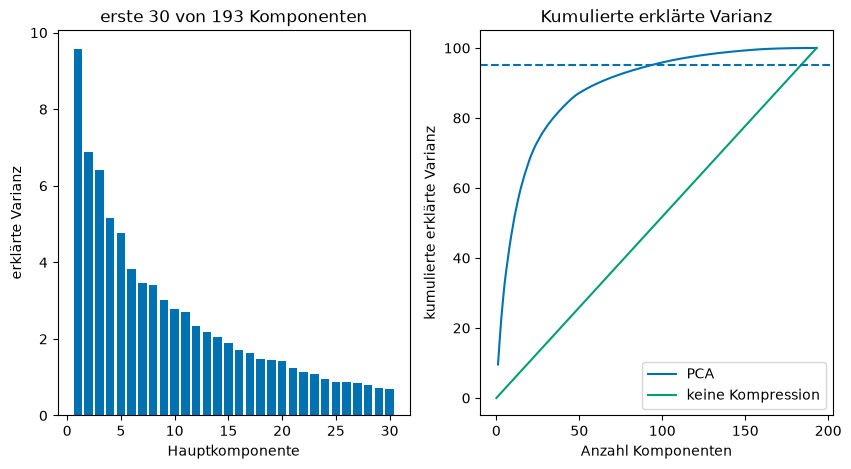

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].bar(range(1,31), erk_var[:30] * 100)
axes[0].set_xlabel("Hauptkomponente")
axes[0].set_ylabel("erklärte Varianz")
axes[0].set_title(f"erste 30 von {len(erk_var)} Komponenten")

axes[1].plot(range(1, len(erk_var_cum) + 1), erk_var_cum * 100, label="PCA")
axes[1].plot([0, len(erk_var_cum)], [0, 100], label="keine Kompression")
axes[1].axhline(95, linestyle="--")
axes[1].set_xlabel("Anzahl Komponenten")
axes[1].set_ylabel("kumulierte erklärte Varianz")
axes[1].set_title("Kumulierte erklärte Varianz")
axes[1].legend()

## Projektion

In [35]:
rng = np.random.default_rng(RANDOM_STATE)
idx_plot = rng.choice(len(x_train_scale), int(0.1 * len(x_train_scale)), replace=False)

pc = pca_voll.transform(x_train_scale[idx_plot])[:,:2]
y_plot = y_train.to_numpy()[idx_plot]

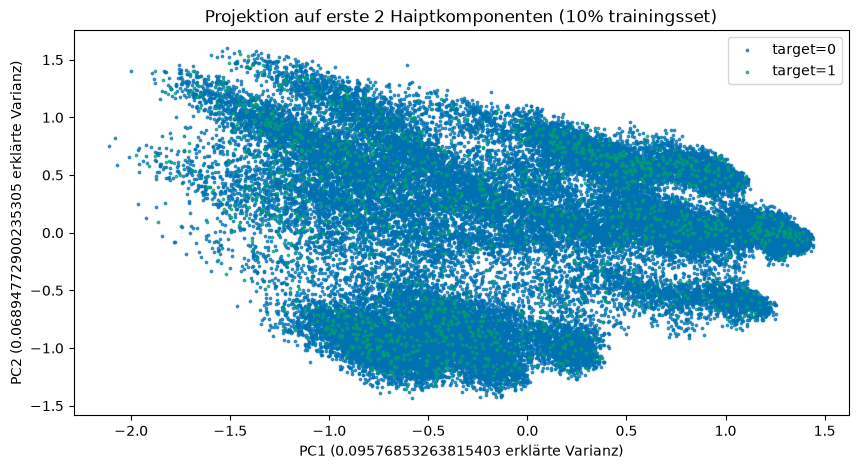

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(*pc[~y_plot].T, label="target=0", s=3, alpha=0.7)
ax.scatter(*pc[y_plot].T, label="target=1", s=3, alpha=0.7)
ax.set_xlabel(f"PC1 ({erk_var[0]} erklärte Varianz)")
ax.set_ylabel(f"PC2 ({erk_var[1]} erklärte Varianz)")
ax.set_title("Projektion auf erste 2 Haiptkomponenten (10% trainingsset)")
ax.legend()

## Logreg test

In [43]:
scaler_targ = MinMaxScaler().fit(x_train_targ)
x_train_targ_scale = scaler_targ.transform(x_train_targ)
x_val_targ_scale = scaler_targ.transform(x_val_targ)

In [44]:
start = time.time()
L_lr_targ = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
).fit(x_train_targ_scale, y_train)
train_times["L_lr_targ"] = time.time() - start

results.append(
    eval_modell("L_lr_targ", L_lr_targ, x_train_targ_scale, y_train, x_val_targ_scale, y_val, train_times["L_lr_targ"])
)

In [45]:
start = time.time()
L_lr_one_hot = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
).fit(x_train_scale, y_train)
train_times["L_lr_one_hot"] = time.time() - start

results.append(
    eval_modell("L_lr_one_hot", L_lr_one_hot, x_train_scale, y_train, x_val_scale, y_val, train_times["L_lr_one_hot"])
)

In [46]:
pd.DataFrame(results)

,model_idx,auc_train,auc_test,gini,delta_auc,best_iter,trainingszeit
0,L_lr_targ,0.633128,0.616282,0.232564,0.016846,None,2.855117
1,L_lr_one_hot,0.634850,0.614756,0.229512,0.020094,None,3.695193


In [47]:
pca_all = PCA(n_components=None, random_state=RANDOM_STATE)

x_train_pca = pca_all.fit_transform(x_train_scale)
x_val_pca = pca_all.transform(x_val_scale)

x_train_pca.shape

(476168, 193)

In [48]:
m_list = [2, 5, 10, 20, 30, 50, 75, 100, 150]

sweep = []

for m in m_list:
    start = time.time()
    modell = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ).fit(x_train_pca[:, :m], y_train)
    train_time = time.time() - start

    row = eval_modell(f"L_lr_pca_{m}", modell, x_train_pca[:, :m], y_train, x_val_pca[:, :m], y_val, train_time)
    row["m"] = m
    row["erklärte Var"] = pca_all.explained_variance_ratio_.cumsum()[m-1]
    sweep.append(row)

df_sweep = pd.DataFrame(sweep)
df_sweep

,model_idx,auc_train,auc_test,gini,delta_auc,best_iter,trainingszeit,m,erklärte Var
0,L_lr_pca_2,0.580502,0.569519,0.139038,0.010983,None,0.122082,2,0.164716
1,L_lr_pca_5,0.593346,0.580505,0.161009,0.012842,None,0.177050,5,0.327908
2,L_lr_pca_10,0.597185,0.582985,0.165970,0.014199,None,0.215054,10,0.492624
3,L_lr_pca_20,0.610511,0.591724,0.183448,0.018787,None,0.232745,20,0.681291
4,L_lr_pca_30,0.614498,0.599619,0.199238,0.014879,None,0.333372,30,0.773249
5,L_lr_pca_50,0.626356,0.614026,0.228053,0.012330,None,0.899235,50,0.871571
6,L_lr_pca_75,0.628866,0.613571,0.227142,0.015295,None,1.097321,75,0.925437
7,L_lr_pca_100,0.631582,0.615050,0.230099,0.016533,None,1.097667,100,0.958785
8,L_lr_pca_150,0.633869,0.615432,0.230864,0.018437,None,1.887817,150,0.993089


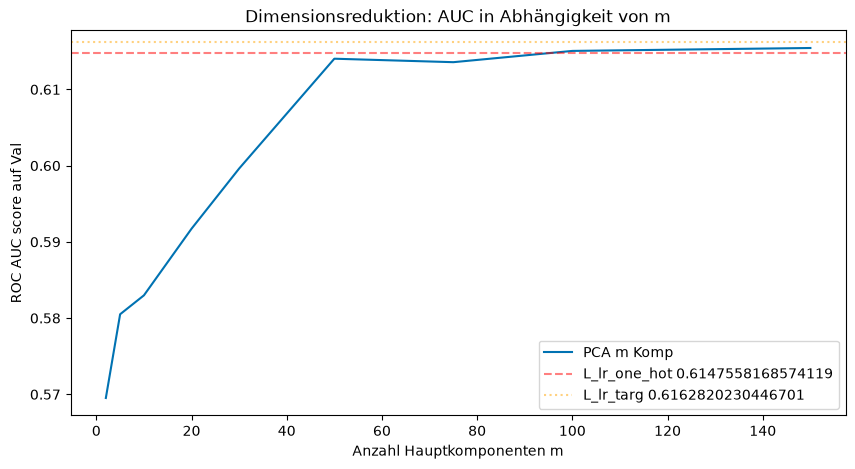

In [56]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sweep["m"], df_sweep["auc_test"], label="PCA m Komp")
ax.axhline(results[1]["auc_test"], linestyle="--", label=f"L_lr_one_hot {results[1]["auc_test"]}", color="red", alpha=0.5)
ax.axhline(results[0]["auc_test"], linestyle=":", label=f"L_lr_targ {results[0]["auc_test"]}", color="orange", alpha=0.5)
ax.set_xlabel("Anzahl Hauptkomponenten m")
ax.set_ylabel("ROC AUC score auf Val")
ax.set_title("Dimensionsreduktion: AUC in Abhängigkeit von m")
ax.legend()

In [57]:
beste = df_sweep.loc[df_sweep["auc_test"].idxmax()]

train_times[beste["model_idx"]] = beste["trainingszeit"]

results.append({
    a: beste[a] for a in ("model_idx", "auc_train", "auc_test", "gini", "delta_auc", "best_iter", "trainingszeit")
})

pd.DataFrame(results).sort_values("auc_test", ascending=False)

,model_idx,auc_train,auc_test,gini,delta_auc,best_iter,trainingszeit
0,L_lr_targ,0.633128,0.616282,0.232564,0.016846,None,2.855117
2,L_lr_pca_150,0.633869,0.615432,0.230864,0.018437,None,1.887817
1,L_lr_one_hot,0.634850,0.614756,0.229512,0.020094,None,3.695193


## Grid Search für LogReg
simplere Grid search aus Zeitgründen, solange ich mir Optuna LogReg anschaue

In [68]:
param_grid = [{
    "C": np.logspace(-3, 2, 11), 
    "penalty": ["l2"],
    "class_weight": [None, "balanced"]
    },
    {
    "penalty": [None],
    "class_weight": [None, "balanced"]
    },
]

In [69]:
grid = []

for name, x_tr, x_va in (
    ("L_lr_targ", x_train_targ_scale, x_val_targ_scale),
    ("L_lr_one_hot", x_train_scale, x_val_scale),
    ("L_lr_pca_93", x_train_pca[:, :93], x_val_pca[:, :93]),
):
    for params in ParameterGrid(param_grid):
        start = time.time()
        modell = LogisticRegression(
            **params, 
            solver="lbfgs", 
            random_state=RANDOM_STATE, 
            max_iter=1000
        ).fit(x_tr, y_train)
        row = eval_modell(f"{name}_{params}", modell, x_tr, y_train, x_va, y_val, time.time() - start)
        row["variante"] = name
        row["C"] = params.get("C", "x")
        row["penalty"] = params["penalty"]
        row["class_weight"] = params["class_weight"]
        grid.append(row)

df_grid = pd.DataFrame(grid)
df_grid.sort_values("auc_test", ascending=False).head(10)

,model_idx,auc_train,auc_test,gini,delta_auc,best_iter,trainingszeit,variante,C,penalty,class_weight
4,"L_lr_targ_{'C': 0.01, 'class_weight': None, 'p...",0.632448,0.617103,0.234207,0.015344,None,2.567018,L_lr_targ,0.01,l2,NaN
3,"L_lr_targ_{'C': 0.0031622776601683794, 'class_...",0.633085,0.616379,0.232759,0.016705,None,2.820789,L_lr_targ,0.003162,l2,balanced
8,"L_lr_targ_{'C': 0.1, 'class_weight': None, 'pe...",0.632986,0.616365,0.232730,0.016621,None,2.557745,L_lr_targ,0.1,l2,NaN
6,"L_lr_targ_{'C': 0.03162277660168379, 'class_we...",0.632916,0.616305,0.232610,0.016611,None,2.750894,L_lr_targ,0.031623,l2,NaN
23,"L_lr_targ_{'class_weight': 'balanced', 'penalt...",0.634103,0.616287,0.232573,0.017817,None,6.310595,L_lr_targ,x,NaN,balanced
12,"L_lr_targ_{'C': 1.0, 'class_weight': None, 'pe...",0.633128,0.616282,0.232564,0.016846,None,2.698913,L_lr_targ,1.0,l2,NaN
19,"L_lr_targ_{'C': 31.622776601683793, 'class_wei...",0.634099,0.616265,0.232530,0.017834,None,6.142005,L_lr_targ,31.622777,l2,balanced
16,"L_lr_targ_{'C': 10.0, 'class_weight': None, 'p...",0.632990,0.616259,0.232518,0.016731,None,2.661736,L_lr_targ,10.0,l2,NaN
18,"L_lr_targ_{'C': 31.622776601683793, 'class_wei...",0.632977,0.616255,0.232510,0.016722,None,2.600756,L_lr_targ,31.622777,l2,NaN
10,"L_lr_targ_{'C': 0.31622776601683794, 'class_we...",0.633037,0.616250,0.232500,0.016787,None,2.378184,L_lr_targ,0.316228,l2,NaN


## Optuna log reg for pca data

In [73]:
x_tr_opt, x_va_opt = x_train_pca[:, :93], x_val_pca[:, :93]

In [74]:
def objective(trial):
    l1_ratio = trial.suggest_categorical("l1_ratio", [0.0, 0.25, 0.5, 0.75, 1.0])

    params = {
        "l1_ratio": l1_ratio,
        "C": trial.suggest_float("C", 1e-3, 1e2, log=True),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "solver": "lbfgs" if l1_ratio == 0.0 else "saga",
        "max_iter": 1000 if l1_ratio == 0.0 else 5000,
        "random_state": RANDOM_STATE
    }

    modell = LogisticRegression(
        **params
    ).fit(x_tr_opt, y_train)

    return roc_auc_score(y_val, modell.predict_proba(x_va_opt)[:, 1])

In [72]:
study_pca_logreg = optuna.create_study(
    study_name="L_lr_pca_opti",
    storage="sqlite:///lr_pca_opti.db",
    load_if_exists = True,
    direction = "maximize",
    sampler = TPESampler(seed=RANDOM_STATE)
)

[I 2026-08-17 17:30:11,931] A new study created in RDB with name: L_lr_pca_opti


In [75]:
study_pca_logreg.optimize(
    objective, 
    n_trials=50,
    timeout=3*60*60,
    catch=(Exception, ),
    show_progress_bar=True
)

pd.Series(study_pca_logreg.best_params | {"auc_val": study_pca_logreg.best_value})

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-17 18:16:01,124] Trial 0 finished with value: 0.5509816155008812 and parameters: {'l1_ratio': 0.25, 'C': 0.0060252157362038605, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5509816155008812.
[I 2026-08-17 18:57:50,374] Trial 1 finished with value: 0.5814713015752252 and parameters: {'l1_ratio': 0.75, 'C': 0.011526449540315618, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.5814713015752252.
[I 2026-08-17 19:40:23,828] Trial 2 finished with value: 0.533767040587906 and parameters: {'l1_ratio': 1.0, 'C': 0.004982752357076452, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.5814713015752252.
[I 2026-08-17 19:40:36,361] Trial 3 finished with value: 0.5986336974682934 and parameters: {'l1_ratio': 0.25, 'C': 0.0017070728830306638, 'class_weight': None}. Best is trial 3 with value: 0.5986336974682934.
[I 2026-08-17 19:40:48,698] Trial 4 finished with value: 0.5983818699907669 and parameters: {'l1_ratio': 0.5, 'C': 0.0030786517836196197, 'class_w

l1_ratio        0.250000
C               0.001707
class_weight         NaN
auc_val         0.598634
dtype: float64

In [76]:
pd.Series([tri.state.name for tri in study_pca_logreg.trials]).value_counts()

COMPLETE    7
Name: count, dtype: int64

In [77]:
best = study_pca_logreg.best_params.copy()
best["solver"] = "lbfgs" if best["l1_ratio"] == 0.0 else "saga"

start = time.time()
L_lr_pca_opt = LogisticRegression(
    **best,
    max_iter=1000,
    random_state=RANDOM_STATE
).fit(x_tr_opt, y_train)
train_times["L_lr_pca_opt"] = time.time() - start

results.append(
    eval_modell("L_lr_pca_opt", L_lr_pca_opt, x_tr_opt, y_train, x_va_opt, y_val, train_times["L_lr_pca_opt"])
)

pd.DataFrame(results).sort_values("auc_test", ascending=False)

,model_idx,auc_train,auc_test,gini,delta_auc,best_iter,trainingszeit
0,L_lr_targ,0.633128,0.616282,0.232564,0.016846,None,2.855117
2,L_lr_pca_150,0.633869,0.615432,0.230864,0.018437,None,1.887817
1,L_lr_one_hot,0.634850,0.614756,0.229512,0.020094,None,3.695193
3,L_lr_pca_opt,0.613576,0.598634,0.197267,0.014942,None,12.169618


## Notizen

- Optuna Lauf hier nicht zu verwerten, muss ich fixen, falls Zeit besteht, aber morgen erstmal mit Eric xgb opti

